In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [3]:
import logging

import torch

from scripts import (
    generate_dataset,
    generate_pred_datasets,
    optuna_search,
    predictions,
    training,
)
from src.utils import configure_logger

logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

#### Debugging optuna

In [4]:
from __future__ import annotations

import logging

import numpy as np
import optuna
import torch
import typer

from qqe.src.GNN.training.datasets import (
    prepare_datasets,
)
from qqe.src.GNN.training.runners import MODEL_REGISTRY
from qqe.src.GNN.training.utils import (
    collect_dataset_paths,
    collect_files_path,
)
from qqe.src.utils import configure_logger

logger = logging.getLogger(__name__)

_AMP_DEVICE_TYPE = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
model_type="gnn"
epochs = 30
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "clifford"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/dataset"
model_save_path = "../outputs/models/clifford_model_gnn.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0


model_hparams = {
    "gnn_hidden": 16,
    "gnn_heads": 6,
    "global_hidden": 128,
    "reg_hidden": 128,
    "num_layers": 3,
    "dropout_rate": 0.10,
}

train_hparams = {
    "weight_decay": 0.0003,
    "grad_clip": 0.04,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

In [10]:
seed = np.random.randint(0, 10000)
logger.info(f"Starting Optuna hyperparameter search...")
data_paths = collect_dataset_paths(
    data_dir,
    family=family if training_mode == "per_family" else None,
    split="target",
)
logger.info(f"Found {len(data_paths)} dataset files for target={target} in data_dir={data_dir}.")

2026-05-18 11:21:06,051 - __main__ - INFO - Starting Optuna hyperparameter search...
2026-05-18 11:23:09,029 - __main__ - INFO - Found 35700 dataset files for target=sre in data_dir=../outputs/data/dataset.


In [11]:
prepared_data = prepare_datasets(
    data_paths,
    loader_kind=model_type,
    seed=seed,
    train_split=0.8,
    val_split=0.1,
    global_feature_variant="binned",
    node_feature_variant=None,
    family_projection=family if training_mode == "per_family" else None,
)

In [14]:
study_name = f"optuna_search_{model_type}_{training_mode}_{family}_{target}_{seed}"
storage_url = f"sqlite:///optuna_studies.db"
n_trials = 5

In [13]:
logger.info(f"Prepared datasets with loader_kind={model_type}. Starting Optuna study with name='{study_name}' and storage='{storage_url}'...")

2026-05-18 11:25:37,820 - __main__ - INFO - Prepared datasets with loader_kind=gnn. Starting Optuna study with name='optuna_search_gnn_per_family_clifford_sre_4119' and storage='sqlite:///optuna_studies.db'...


In [15]:
study = optuna.create_study(
    study_name=study_name,
    direction="minimize",
    storage=storage_url,
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(seed=seed),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5, n_startup_trials=10),
)

def objective_fn(trial):
    return MODEL_REGISTRY[model_type]["objective_fn"](
        trial,
        prepared_data=prepared_data,
        epochs=epochs,
    )
logger.info(f"Running Optuna optimization for {n_trials} trials...")
study.optimize(objective_fn, n_trials=n_trials, gc_after_trial=True)

[I 2026-05-18 11:26:05,545] A new study created in RDB with name: optuna_search_gnn_per_family_clifford_sre_4119
2026-05-18 11:26:05,548 - __main__ - INFO - Running Optuna optimization for 5 trials...
2026-05-18 11:26:06,010 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------
2026-05-18 11:27:06,169 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 190/804 | loss 3.912660 | elapsed 60.2s | graphs 6080
2026-05-18 11:28:06,298 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 360/804 | loss 2.964534 | elapsed 120.3s | graphs 11520
2026-05-18 11:29:06,470 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 523/804 | loss 2.444126 | elapsed 180.5s | graphs 16736
2026-05-18 11:30:06,899 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 657/804 | loss 2.168187 | elapsed 240.9s | graphs 21024
2026-05-18 11:31:07,225 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 793/804 | loss 1.951924 | elapsed 301.2s | grap

# Optimizing models

## GNN

In [16]:
model_type="gnn"
epochs = 30
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/dataset"
model_save_path = "../outputs/models/random_model_gnn.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
study_name = f"optuna_search_{model_type}_{training_mode}_{family}_{target}_{seed}"
storage_url = f"sqlite:///optuna_studies.db"
n_trials = 10

In [ ]:
{'batch_size': 16, 'weight_decay': 0.0003546212126918109, 'grad_clip': 0.031369743908464774, 'gnn_hidden': 32, 'gnn_heads': 4, 'global_hidden': 64, 'reg_hidden': 16, 'num_layers': 6, 'dropout_rate': 0.16706832478693956, 'lr': 4.713739768368574e-05, 'loss_type': 'mse'}.

In [17]:
optuna_search(
    model_type=model_type,
    training_mode=training_mode,
    family=family,
    data_dir=data_dir,
    target=target,
    study_name=study_name,
    storage_url=storage_url,
    n_trials=n_trials,
)

2026-05-18 14:01:46,770 - scripts.optuna_search - INFO - Starting Optuna hyperparameter search...
2026-05-18 14:04:06,760 - scripts.optuna_search - INFO - Found 35700 dataset files for target=sre in data_dir=../outputs/data/dataset.
2026-05-18 14:05:51,978 - scripts.optuna_search - INFO - Prepared datasets with loader_kind=gnn. Starting Optuna study with name='optuna_search_gnn_per_family_random_sre_4119' and storage='sqlite:///optuna_studies.db'...
[I 2026-05-18 14:05:52,044] A new study created in RDB with name: optuna_search_gnn_per_family_random_sre_4119
2026-05-18 14:05:52,047 - scripts.optuna_search - INFO - Running Optuna optimization for 10 trials...
2026-05-18 14:05:52,162 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------
2026-05-18 14:06:52,341 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 165/201 | loss 1.430501 | elapsed 60.2s | graphs 21120
2026-05-18 14:07:05,257 - qqe.src.GNN.training.train - INFO - Training complete (73.1s) | running va

## NN

In [6]:
model_type="gnn"
epochs = 30
lr = 1e-4
seed = np.random.randint(0, 10000)
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "global"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/dataset"
model_save_path = "../outputs/models/random_global_model_gnn.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
study_name = f"optuna_search_{model_type}_{training_mode}_{family}_{target}_{seed}"
storage_url = f"sqlite:///optuna_studies.db"
n_trials = 10

In [7]:
optuna_search(
    model_type=model_type,
    training_mode=training_mode,
    family=family,
    data_dir=data_dir,
    target=target,
    study_name=study_name,
    storage_url=storage_url,
    n_trials=n_trials,
)

2026-05-19 17:08:55,047 - scripts.optuna_search - INFO - Starting Optuna hyperparameter search...
2026-05-19 17:18:50,621 - scripts.optuna_search - INFO - Found 142800 dataset files for target=sre in data_dir=../outputs/data/dataset.
2026-05-19 17:25:33,218 - scripts.optuna_search - INFO - Prepared datasets with loader_kind=gnn. Starting Optuna study with name='optuna_search_gnn_global_random_sre_2077' and storage='sqlite:///optuna_studies.db'...
[I 2026-05-19 17:25:33,900] A new study created in RDB with name: optuna_search_gnn_global_random_sre_2077
2026-05-19 17:25:33,903 - scripts.optuna_search - INFO - Running Optuna optimization for 10 trials...
2026-05-19 17:25:34,382 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------
2026-05-19 17:26:35,726 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 51/1607 | loss 1.334693 | elapsed 61.3s | graphs 3264
2026-05-19 17:27:36,808 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 113/1607 | loss 0.86

KeyboardInterrupt: 

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import ast

from qqe.src.experiments.plotting import view_correlation

def to_scalar(x):
    # Already numeric
    if isinstance(x, (int, float)):
        return x

    # torch / numpy scalar
    if hasattr(x, "item"):
        return x.item()

    # Strings
    if isinstance(x, str):
        x = x.strip()

        # Handle tensor(...) by stripping wrapper FIRST
        if x.startswith("tensor(") and x.endswith(")"):
            x = x[len("tensor("):-1].strip()

        try:
            val = ast.literal_eval(x)
        except Exception:
            # fallback: plain float string
            return float(x)

        # If it's a list/tuple like [10]
        if isinstance(val, (list, tuple)):
            if len(val) == 1:
                return float(val[0])
            raise ValueError(f"Unexpected list length: {val}")

        return float(val)

    raise ValueError(f"Unsupported type: {type(x)}")

In [49]:
cliff_df = pd.read_csv("../outputs/predictions/family/gnn_predictions_clifford.csv")

In [50]:
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    cliff_df[col] = cliff_df[col].apply(to_scalar).astype(int)

In [51]:
cliff_df.head()

,cid,family,seed,n_qubits,n_layers,target,prediction,error
0,clifford_Q10_L100_S1008105898,clifford,1008105898,10,100,7.645770e+00,7.552979,0.092791
1,clifford_Q10_L100_S1017900085,clifford,1017900085,10,100,7.921119e+00,8.384588,0.463470
2,clifford_Q10_L100_S1054497654,clifford,1054497654,10,100,7.997794e+00,8.230921,0.233127
3,clifford_Q10_L100_S1054752587,clifford,1054752587,10,100,2.655640e-13,0.197006,0.197006
4,clifford_Q10_L100_S1059777886,clifford,1059777886,10,100,8.008198e+00,8.877823,0.869625


In [52]:
cliff_q_l = cliff_df.copy()
cliff_q_l = cliff_q_l[(cliff_q_l["n_qubits"] == 10) & (cliff_q_l["n_layers"] == 80)]

Text(0.5, 1.0, 'True vs Predicted SRE for Clifford Family (GNN Model)')

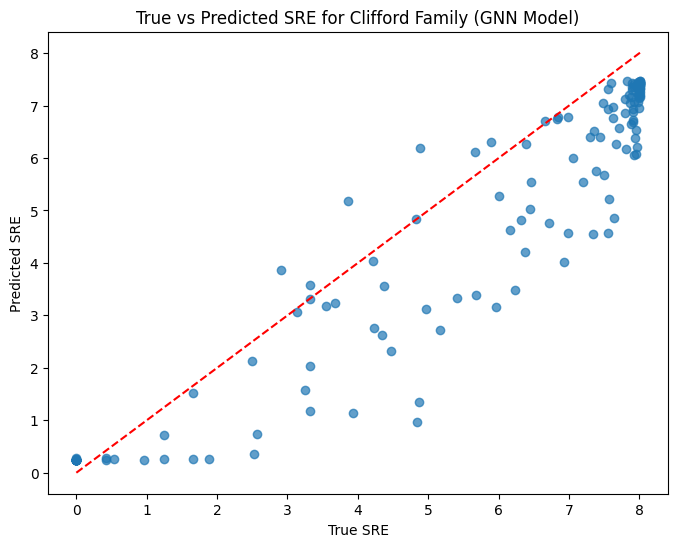

In [53]:
plt.figure(figsize=(8, 6))
plt.scatter(cliff_q_l["target"], cliff_q_l["prediction"], alpha=0.7)
plt.plot([cliff_q_l["target"].min(), cliff_q_l["target"].max()], [cliff_q_l["target"].min(), cliff_q_l["target"].max()], 'r--')  # y=x line
plt.xlabel("True SRE")
plt.ylabel("Predicted SRE")
plt.title("True vs Predicted SRE for Clifford Family (GNN Model)")

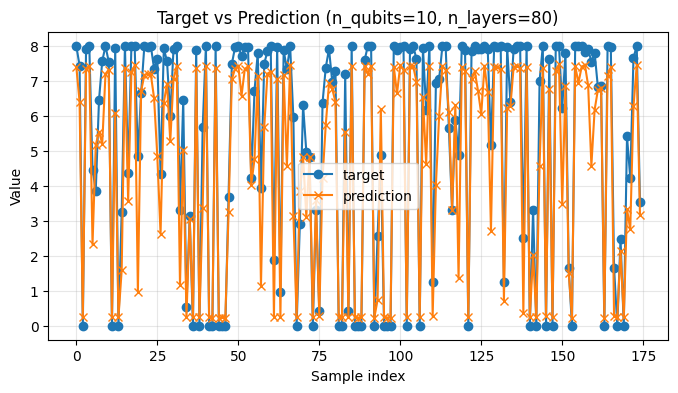

Pearson r = 0.9592


In [54]:
view_correlation(
    cliff_q_l,
    nq=10,
    nl=80,
    col_x="target",
    col_y="prediction",
)